# James Torres
## CSCI E-89 Assignment 03, Problem 2

This notebook builds the "Building an Image Classifier with PyTorch" example from
Géron's *Hands-On Machine Learning with Scikit-Learn and PyTorch* (2025),
chapter 10. It loads Fashion MNIST and splits the training images into 55,000
for training and 5,000 for validation. It then defines a multilayer perceptron
(784 → 300 → 100 → 10) that outputs raw logits and trains it with SGD
(lr = 0.1) and cross-entropy loss for 20 epochs, tracking training and
validation accuracy with torchmetrics. Finally it plots the accuracy curves,
reloads the saved weights to measure test-set accuracy, and inspects the
predicted classes and softmax probabilities for a few validation images. The
code is the five step scripts (`step1_data.py` through `step5_evaluate.py`)
combined, with the cross-script imports removed.

## Imports

All libraries used across the five steps, imported once.

In [1]:
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split

## Step 1: Data

### Device selection

`get_device()` returns `"cuda"` if an NVIDIA GPU is available, `"mps"` on Apple
Silicon, and `"cpu"` otherwise.

In [2]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    return "cpu"

### Datasets and data loaders

`get_datasets()` downloads Fashion MNIST to `datasets/` and converts each image
to a float32 tensor scaled to [0, 1]. It then splits the 60,000 training images
into 55,000 for training and 5,000 for validation, with seed 42.
`get_loaders()` wraps the three sets in `DataLoader`s, shuffling only the
training set, and also returns the class names.

In [3]:
def get_datasets():
    toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
    train_and_valid_data = torchvision.datasets.FashionMNIST(
        root="datasets", train=True, download=True, transform=toTensor)
    test_data = torchvision.datasets.FashionMNIST(
        root="datasets", train=False, download=True, transform=toTensor)
    torch.manual_seed(42)
    train_data, valid_data = random_split(train_and_valid_data, [55_000, 5_000])
    return train_data, valid_data, test_data


def get_loaders(batch_size=32):
    train_data, valid_data, test_data = get_datasets()
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_data, batch_size=batch_size)
    test_loader = DataLoader(test_data, batch_size=batch_size)
    class_names = test_data.classes
    return train_loader, valid_loader, test_loader, class_names

### Inspect a training sample

Print the shape, dtype and class name of the first training image, plus the
device that will be used.

In [4]:
train_data, valid_data, test_data = get_datasets()
class_names = test_data.classes
X_sample, y_sample = train_data[0]
print("Shape:", X_sample.shape)
print("Dtype:", X_sample.dtype)
print("Class:", class_names[y_sample])
print("Device:", get_device())

Shape: torch.Size([1, 28, 28])
Dtype: torch.float32
Class: Ankle boot
Device: cpu


## Step 2: Model

### The `ImageClassifier` MLP

The model flattens each 28×28 image to 784 inputs and passes it through two
hidden layers (300 and 100 units, ReLU) to a 10-unit output layer. It returns
raw logits with no softmax, because `nn.CrossEntropyLoss` applies softmax
itself.

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=28 * 28, n_hidden1=300, n_hidden2=100,
                 n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, X):
        return self.mlp(X)  # raw logits; CrossEntropyLoss applies softmax

### Parameter count and output shape

Build the model with seed 42, count its trainable parameters, and run one batch
of 32 images through it to check that the output shape is `[32, 10]`.

In [6]:
device = get_device()
torch.manual_seed(42)
model = ImageClassifier().to(device)
n_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", n_params)

train_loader, valid_loader, test_loader, class_names = get_loaders()
X_batch, y_batch = next(iter(train_loader))
with torch.no_grad():
    logits = model(X_batch.to(device))
print("Input batch shape:", X_batch.shape)
print("Output shape:", logits.shape)

Total parameters: 266610
Input batch shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])


## Step 3: Training

### Evaluation and training functions

`evaluate_tm()` computes a torchmetrics metric over a whole data loader in eval
mode. `train()` follows Géron's `train2`. Each epoch it runs SGD over the
training batches and records the mean training loss and training accuracy, then
calls `evaluate_tm()` for validation accuracy. It prints the three values and
returns them as a history dict.

In [7]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    device = next(model.parameters()).device
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    device = next(model.parameters()).device
    history = {"train_loss": [], "train_acc": [], "valid_acc": []}
    for epoch in range(n_epochs):
        model.train()
        metric.reset()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_loss"].append(mean_loss)
        history["train_acc"].append(metric.compute().item())
        history["valid_acc"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_loss'][-1]:.4f}, "
              f"train metric: {history['train_acc'][-1]:.4f}, "
              f"valid metric: {history['valid_acc'][-1]:.4f}")
    return history

### Train for 20 epochs

Build a fresh model with seed 42 and train it with SGD (lr = 0.1) and
cross-entropy loss for 20 epochs. Then save the learning curves to
`history.json` and the weights to `model.pt`.

In [8]:
device = get_device()
train_loader, valid_loader, test_loader, class_names = get_loaders()
torch.manual_seed(42)
model = ImageClassifier().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=10).to(device)
history = train(model, optimizer, loss_fn, accuracy, train_loader,
                valid_loader, n_epochs=20)
with open("history.json", "w") as f:
    json.dump(history, f, indent=2)
torch.save(model.state_dict(), "model.pt")
print("Saved history.json and model.pt")

Epoch 1/20, train loss: 0.6060, train metric: 0.7816, valid metric: 0.8418


Epoch 2/20, train loss: 0.4063, train metric: 0.8491, valid metric: 0.8420


Epoch 3/20, train loss: 0.3641, train metric: 0.8654, valid metric: 0.8536


Epoch 4/20, train loss: 0.3352, train metric: 0.8773, valid metric: 0.8676


Epoch 5/20, train loss: 0.3149, train metric: 0.8840, valid metric: 0.8768


...

Epoch 16/20, train loss: 0.2091, train metric: 0.9199, valid metric: 0.8834


Epoch 17/20, train loss: 0.2032, train metric: 0.9227, valid metric: 0.8906


Epoch 18/20, train loss: 0.1985, train metric: 0.9237, valid metric: 0.8844


Epoch 19/20, train loss: 0.1937, train metric: 0.9262, valid metric: 0.8834


Epoch 20/20, train loss: 0.1881, train metric: 0.9287, valid metric: 0.8766
Saved history.json and model.pt


## Step 4: Accuracy plot

### Plotting functions

`load_history()` reads `history.json`. `plot_accuracy()` draws training and
validation accuracy per epoch on the same axes and saves the figure as
`training_accuracy.png`.

In [9]:
TRAIN_COLOR = "#2a78d6"  # blue
VALID_COLOR = "#eb6834"  # orange


def load_history(path="history.json"):
    with open(path) as f:
        return json.load(f)


def plot_accuracy(history, path="training_accuracy.png"):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, history["train_acc"], color=TRAIN_COLOR, linewidth=2,
            marker="o", markersize=6, label="Training accuracy")
    ax.plot(epochs, history["valid_acc"], color=VALID_COLOR, linewidth=2,
            marker="s", markersize=6, label="Validation accuracy")
    ax.set_title("Fashion MNIST MLP: Accuracy per Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(list(epochs))
    ax.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    return fig

### Plot the learning curves

Load the history saved during training and show the accuracy plot inline.

Saved training_accuracy.png


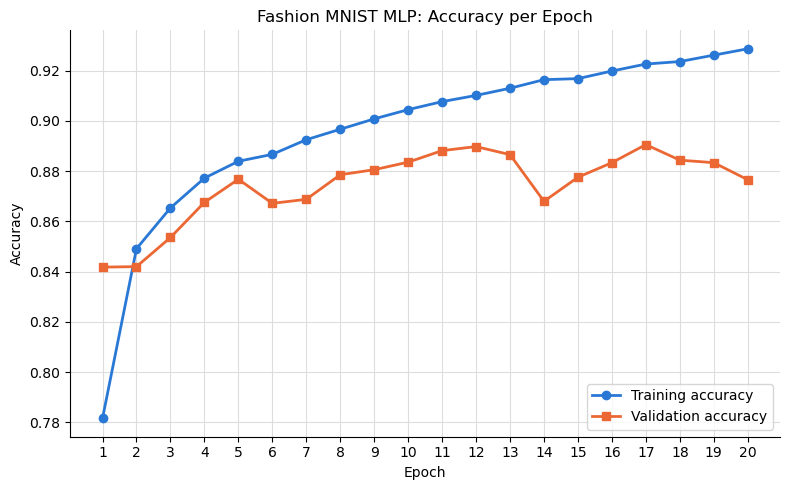

In [10]:
history = load_history()
plot_accuracy(history)
print("Saved training_accuracy.png")
plt.show()

## Step 5: Evaluation

### Reload the saved model

`load_model()` rebuilds `ImageClassifier`, loads the weights from `model.pt`,
and switches the model to eval mode.

In [11]:
def load_model(path="model.pt", device="cpu"):
    model = ImageClassifier().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

### Test-set accuracy

Reload the trained model from disk and measure its accuracy on the 10,000 test
images.

In [12]:
device = get_device()
train_loader, valid_loader, test_loader, class_names = get_loaders()
model = load_model(device=device)

accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=10).to(device)
test_acc = evaluate_tm(model, test_loader, accuracy).item()
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8755


### Predictions for three validation images

Following Géron, take the first 3 validation images and print the predicted and
true classes, the softmax probabilities rounded to 3 decimals, and each image's
top-4 classes with their probabilities.

In [13]:
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()
print("\nPredicted class indices:", y_pred)
print("Predicted class names:  ", [class_names[i] for i in y_pred])
print("True class indices:     ", y_new)
print("True class names:       ", [class_names[i] for i in y_new])

y_proba = F.softmax(y_pred_logits, dim=1).cpu()
print("\nSoftmax probabilities:")
print(y_proba.round(decimals=3))

y_top4_proba, y_top4 = torch.topk(y_proba, k=4, dim=1)
print("\nTop-4 classes:")
for n, (classes, probas) in enumerate(zip(y_top4, y_top4_proba)):
    top4 = ", ".join(f"{class_names[c]} ({p:.3f})"
                     for c, p in zip(classes, probas))
    print(f"  Image {n}: {top4}")


Predicted class indices: tensor([7, 4, 2])
Predicted class names:   ['Sneaker', 'Coat', 'Pullover']
True class indices:      tensor([7, 4, 2])
True class names:        ['Sneaker', 'Coat', 'Pullover']

Softmax probabilities:
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9200, 0.0000,
         0.0800],
        [0.0000, 0.0000, 0.0030, 0.0000, 0.9970, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0000, 0.7370, 0.0000, 0.0960, 0.0000, 0.1650, 0.0000, 0.0000,
         0.0000]])

Top-4 classes:
  Image 0: Sneaker (0.920), Ankle boot (0.080), Sandal (0.000), Bag (0.000)
  Image 1: Coat (0.997), Pullover (0.003), Shirt (0.000), Bag (0.000)
  Image 2: Pullover (0.737), Shirt (0.165), Coat (0.096), T-shirt/top (0.001)
